In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/hashes.txt
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/database.sqlite


In [3]:
pip install pandas numpy scikit-learn nltk matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
df=pd.read_csv("/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv")

In [6]:
df=df[['Text','Score']]
df.head()

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


In [7]:
# create sentiment labels
def sentiment(score):
    if score > 3:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['Score'].apply(sentiment)

df = df[['Text','Sentiment']]

In [8]:
# text cleaning
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = ''.join([i for i in text if i not in string.punctuation])

    words = text.split()

    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

df['Clean_Text'] = df['Text'].apply(clean_text)

In [9]:
# tf-idf
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['Clean_Text'])

y = df['Sentiment']

In [10]:
# train test split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
# train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
# prediction
y_pred=model.predict(X_test)

In [13]:
# accuracy
print("Accuracy:",accuracy_score(y_test, y_pred))

Accuracy: 0.8664538090086287


In [14]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.73      0.67      0.70     16181
     Neutral       0.52      0.18      0.27      8485
    Positive       0.90      0.97      0.93     89025

    accuracy                           0.87    113691
   macro avg       0.72      0.61      0.63    113691
weighted avg       0.85      0.87      0.85    113691



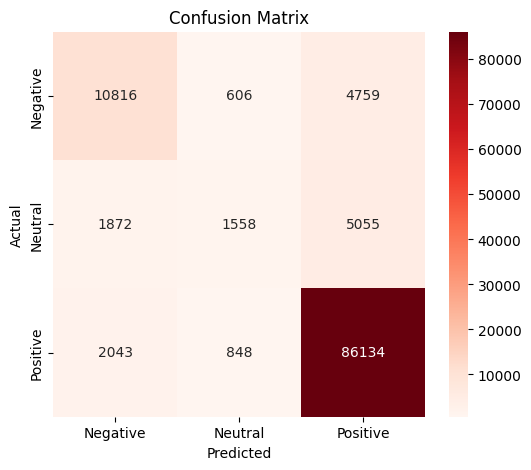

In [15]:
# confusion matrix
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()